# Final Proje — Erken Alzheimer Teşhisi (Birleşik Model)

**Medikal Görüntü İşleme — Dönem Projesi**

Bu notebook, dersin teknik ödevlerini tek bir uçtan-uca hatta birleştirir.

| Bölüm | Ödev karşılığı |
|-------|----------------|
| Görüntü işleme galerisi (CLAHE, histogram eşitleme, Sobel/Canny, morfoloji) | **Ödev 3** |
| Otsu tabanlı beyin segmentasyonu (maske + 3 doku) | **Ödev 4** |
| Albumentations augmentasyon (sınıf dengeleme) | **Ödev 5** |
| El-yapımı özellik (HoG/SIFT/GLCM) + Random Forest baseline | **Ödev 6** |
| **Ana model:** ResNet18 transfer learning + Grad-CAM + ROC | Final |

> Ana model: ImageNet ön-eğitimli **ResNet18** transfer learning ile MR görüntülerinden
> derin özellik çıkarılır ve 4 sınıf ayırt edilir: `Mild_Demented`, `Moderate_Demented`,
> `Non_Demented`, `Very_Mild_Demented`. Ortam **CPU**; model hafif tutulmuştur.

## 0. Kurulum ve Yapılandırma

In [1]:
import io, time, random, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision.models import resnet18, ResNet18_Weights

import albumentations as A
from skimage.feature import hog, graycomatrix, graycoprops
from skimage.filters import threshold_multiotsu
from scipy.stats import skew, kurtosis
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, accuracy_score, confusion_matrix,
                             roc_curve, auc)

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

DATA_DIR   = Path(r"C:\Users\Memit\Desktop\Final\Medikal\early-alzheimer\data")
OUTPUT_DIR = Path(r"C:\Users\Memit\Desktop\Final\Medikal\AlzheimerFinalProje\outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cpu")
CLASS_NAMES = ["Mild_Demented", "Moderate_Demented", "Non_Demented", "Very_Mild_Demented"]
NUM_CLASSES = len(CLASS_NAMES)
IMG_SIZE = 128

IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32).reshape(3, 1, 1)
IMAGENET_STD  = np.array([0.229, 0.224, 0.225], dtype=np.float32).reshape(3, 1, 1)

# SMOKE_TEST=True -> hizli kontrol; False -> tam egitim (gercek sonuclar)
SMOKE_TEST = False
if SMOKE_TEST:
    TARGET_PER_CLASS, RAW_CAP, FT_EPOCHS, RF_PER_CLASS = 40, 25, 2, 40
else:
    TARGET_PER_CLASS, RAW_CAP, FT_EPOCHS, RF_PER_CLASS = 400, 400, 12, 200

print("PyTorch", torch.__version__, "| cihaz:", DEVICE, "| SMOKE_TEST:", SMOKE_TEST)

C:\Users\Memit\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch 2.11.0+cpu | cihaz: cpu | SMOKE_TEST: False


## 1. Veri Yükleme

In [2]:
TRAIN_PATH = DATA_DIR / "train-00000-of-00001-c08a401c53fe5312.parquet"
TEST_PATH  = DATA_DIR / "test-00000-of-00001-44110b9df98c5585.parquet"
train_df = pd.read_parquet(TRAIN_PATH)
test_df  = pd.read_parquet(TEST_PATH)

def decode_image(cell):
    return np.array(Image.open(io.BytesIO(cell["bytes"])).convert("L"))

# Veri setinin orijinal train/test bolunmesi kullanilir
pool_cells  = list(train_df["image"]) + list(test_df["image"])
pool_labels = np.concatenate([train_df["label"].to_numpy(), test_df["label"].to_numpy()])
pool_gray   = [decode_image(c) for c in pool_cells]
n_tr = len(train_df)
train_idx = np.arange(n_tr)
test_idx  = np.arange(n_tr, len(pool_gray))

print(f"Train: {len(train_idx)} | Test: {len(test_idx)} | boyut {pool_gray[0].shape}")
print("Train/sinif:", {CLASS_NAMES[i]: int((pool_labels[train_idx]==i).sum()) for i in range(NUM_CLASSES)})
print("Test /sinif:", {CLASS_NAMES[i]: int((pool_labels[test_idx]==i).sum()) for i in range(NUM_CLASSES)})

Train: 5120 | Test: 1280 | boyut (128, 128)
Train/sinif: {'Mild_Demented': 724, 'Moderate_Demented': 49, 'Non_Demented': 2566, 'Very_Mild_Demented': 1781}
Test /sinif: {'Mild_Demented': 172, 'Moderate_Demented': 15, 'Non_Demented': 634, 'Very_Mild_Demented': 459}


## 2. Keşifsel Veri Analizi (EDA)

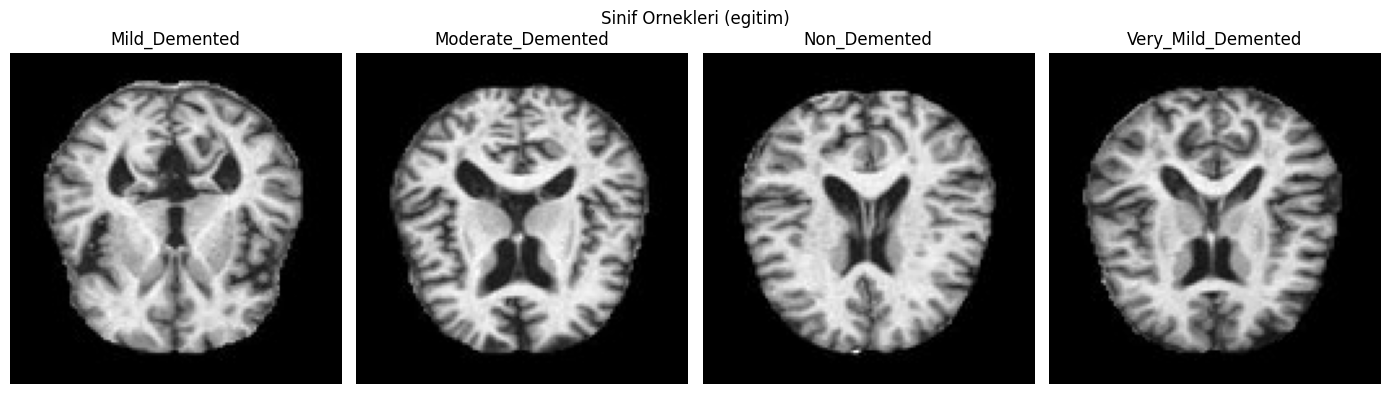

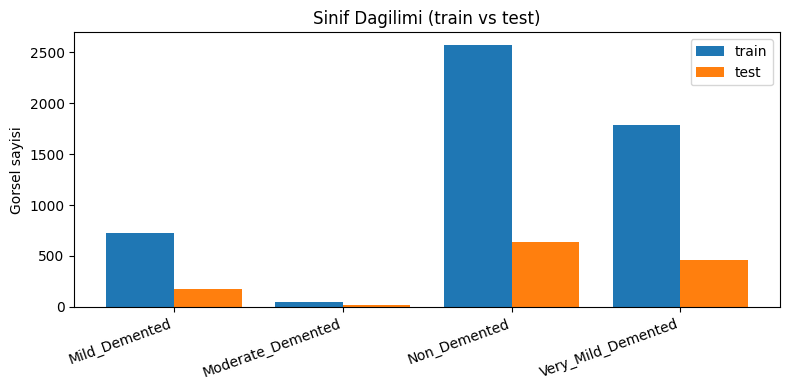

In [3]:
fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(14, 4))
for ax, c in zip(axes, range(NUM_CLASSES)):
    i = train_idx[np.where(pool_labels[train_idx] == c)[0][0]]
    ax.imshow(pool_gray[i], cmap="gray"); ax.set_title(CLASS_NAMES[c]); ax.axis("off")
plt.suptitle("Sinif Ornekleri (egitim)"); plt.tight_layout()
plt.savefig(OUTPUT_DIR / "b_eda_samples.png", dpi=130, bbox_inches="tight"); plt.show()

tr_counts = [int((pool_labels[train_idx]==i).sum()) for i in range(NUM_CLASSES)]
te_counts = [int((pool_labels[test_idx]==i).sum()) for i in range(NUM_CLASSES)]
x = np.arange(NUM_CLASSES); w = 0.4
plt.figure(figsize=(8, 4))
plt.bar(x-w/2, tr_counts, w, label="train"); plt.bar(x+w/2, te_counts, w, label="test")
plt.xticks(x, CLASS_NAMES, rotation=20, ha="right"); plt.ylabel("Gorsel sayisi")
plt.title("Sinif Dagilimi (train vs test)"); plt.legend(); plt.tight_layout()
plt.savefig(OUTPUT_DIR / "b_eda_distribution.png", dpi=130, bbox_inches="tight"); plt.show()

## 3. Görüntü İşleme Galerisi (Ödev 3)

Kontrast iyileştirme (Histogram Eşitleme, CLAHE), gürültü azaltma (Gaussian) ve kenar/morfoloji
(Sobel, Canny, Laplacian, morfolojik gradyan) — beyin MR ön-işlemenin temel teknikleri.

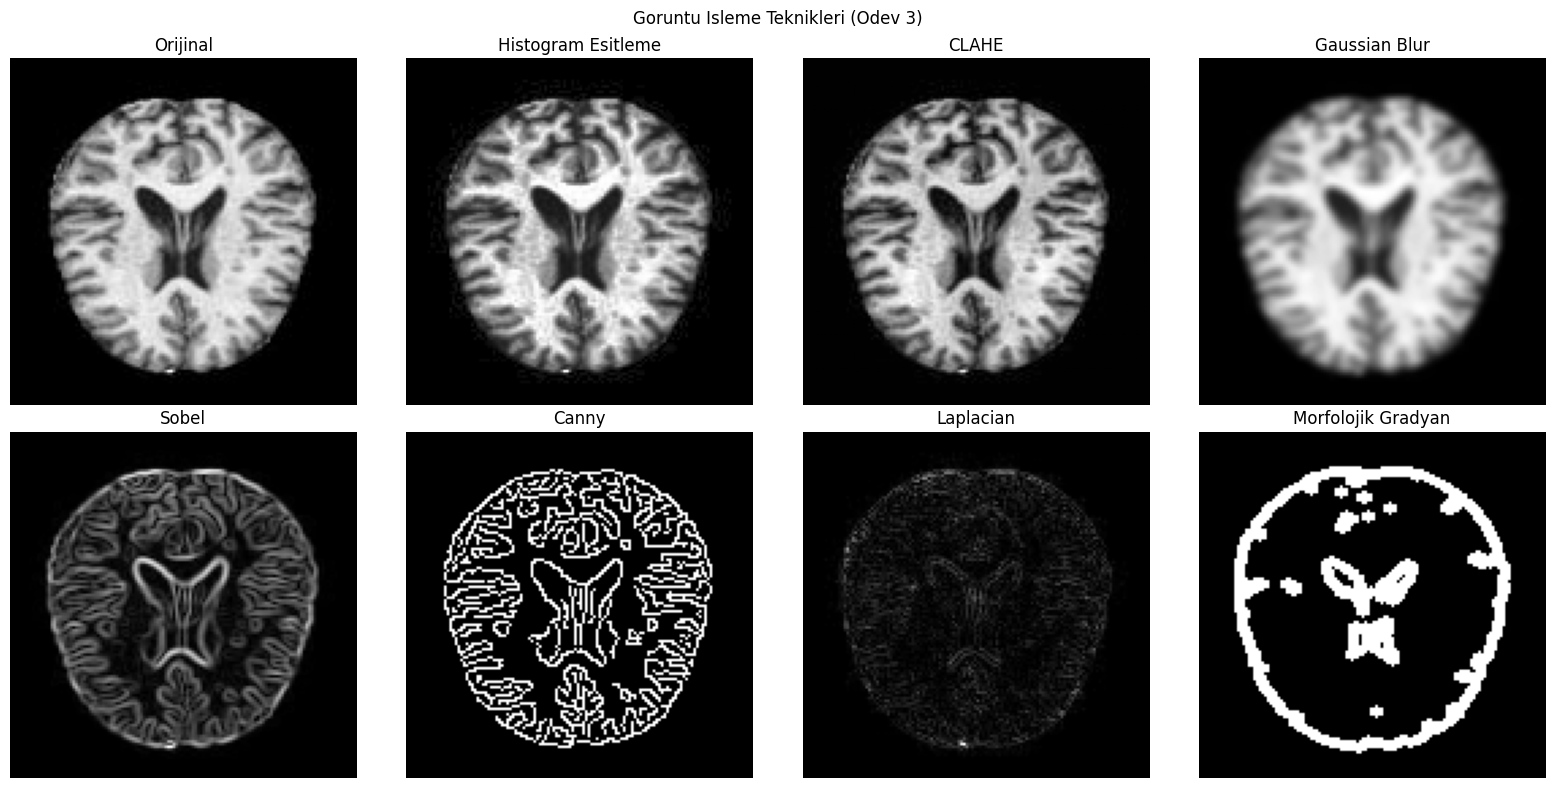

In [4]:
s = pool_gray[train_idx[0]]
_clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
sx = cv2.Sobel(s, cv2.CV_64F, 1, 0, ksize=3); sy = cv2.Sobel(s, cv2.CV_64F, 0, 1, ksize=3)
_, binimg = cv2.threshold(s, 30, 255, cv2.THRESH_BINARY)
kern = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))

row1 = [(s, "Orijinal"), (cv2.equalizeHist(s), "Histogram Esitleme"),
        (_clahe.apply(s), "CLAHE"), (cv2.GaussianBlur(s, (5, 5), 1.5), "Gaussian Blur")]
row2 = [(np.sqrt(sx**2 + sy**2), "Sobel"), (cv2.Canny(s, 50, 150), "Canny"),
        (np.abs(cv2.Laplacian(s, cv2.CV_64F)), "Laplacian"),
        (cv2.morphologyEx(binimg, cv2.MORPH_GRADIENT, kern), "Morfolojik Gradyan")]
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, (im, t) in zip(axes[0], row1): ax.imshow(im, cmap="gray"); ax.set_title(t); ax.axis("off")
for ax, (im, t) in zip(axes[1], row2): ax.imshow(im, cmap="gray"); ax.set_title(t); ax.axis("off")
plt.suptitle("Goruntu Isleme Teknikleri (Odev 3)"); plt.tight_layout()
plt.savefig(OUTPUT_DIR / "b_gallery.png", dpi=130, bbox_inches="tight"); plt.show()

## 4. Otsu Tabanlı Segmentasyon (Ödev 4)

CLAHE+Blur → Otsu ile beyin maskesi (en büyük bileşen + morfoloji) → Multi-Otsu ile 3 doku
sınıfı (CSF / gri madde / beyaz madde benzeri).

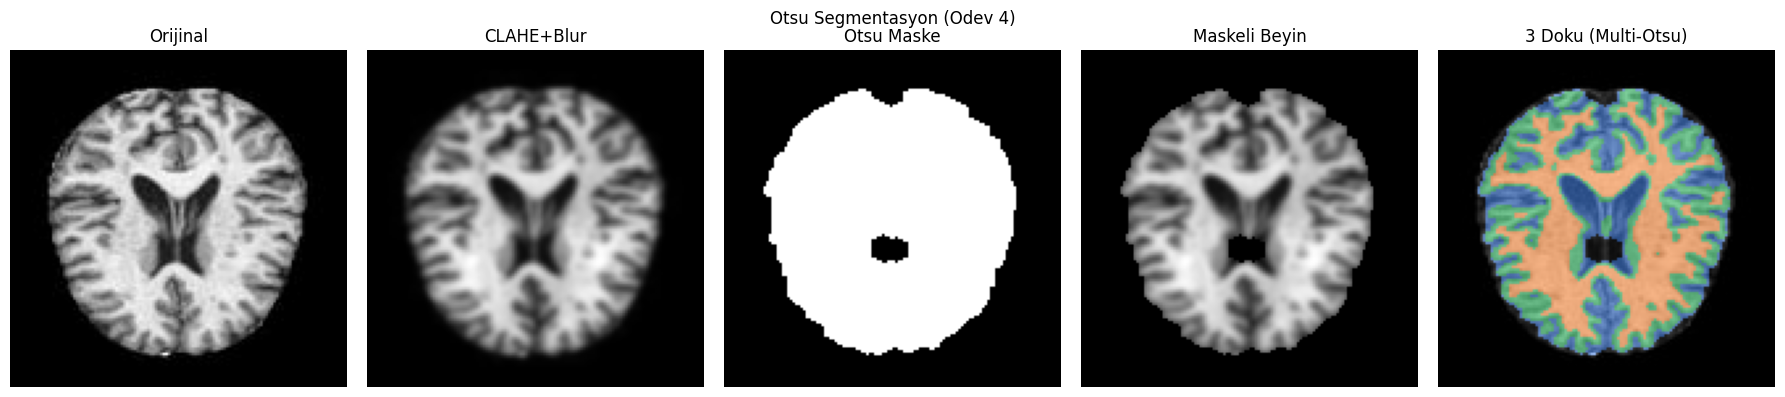

In [5]:
def preprocess_clahe(gray):
    return cv2.GaussianBlur(_clahe.apply(gray), (5, 5), 0)

def segment_brain_otsu(pre):
    _, mask = cv2.threshold(pre, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    n, lab, stats, _ = cv2.connectedComponentsWithStats(mask, 8)
    if n > 1:
        largest = 1 + int(np.argmax(stats[1:, cv2.CC_STAT_AREA]))
        mask = np.where(lab == largest, 255, 0).astype(np.uint8)
    k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, k, iterations=2)
    return cv2.morphologyEx(mask, cv2.MORPH_OPEN, k, iterations=1)

def tissue_overlay(pre, mask):
    inside = mask > 0
    th = threshold_multiotsu(pre[inside], classes=3)
    tmap = np.digitize(pre, bins=th)
    colors = np.array([[59,130,246],[34,197,94],[249,115,22]], np.uint8)
    ov = np.zeros((*pre.shape, 3), np.uint8); ov[inside] = colors[tmap[inside]]
    return ov

g = pool_gray[train_idx[0]]
pre = preprocess_clahe(g); mask = segment_brain_otsu(pre)
masked = cv2.bitwise_and(pre, pre, mask=mask); ov = tissue_overlay(pre, mask)
panel = [(g, "Orijinal"), (pre, "CLAHE+Blur"), (mask, "Otsu Maske"), (masked, "Maskeli Beyin")]
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for ax, (im, t) in zip(axes[:4], panel): ax.imshow(im, cmap="gray"); ax.set_title(t); ax.axis("off")
axes[4].imshow(g, cmap="gray"); axes[4].imshow(ov, alpha=0.5)
axes[4].set_title("3 Doku (Multi-Otsu)"); axes[4].axis("off")
plt.suptitle("Otsu Segmentasyon (Odev 4)"); plt.tight_layout()
plt.savefig(OUTPUT_DIR / "b_segmentation.png", dpi=130, bbox_inches="tight"); plt.show()

## 5. Veri Hazırlama: CLAHE + Augmentasyon (Ödev 5)

Modele **CLAHE ile iyileştirilmiş** görüntüler verilir. Eğitim seti, az örnekli sınıflar
augmentasyonla hedef sayıya tamamlanarak **dengelenir**.

Train: (1600, 128, 128) dagilim [400 400 400 400]
Test : (1280, 128, 128) dagilim [172  15 634 459]


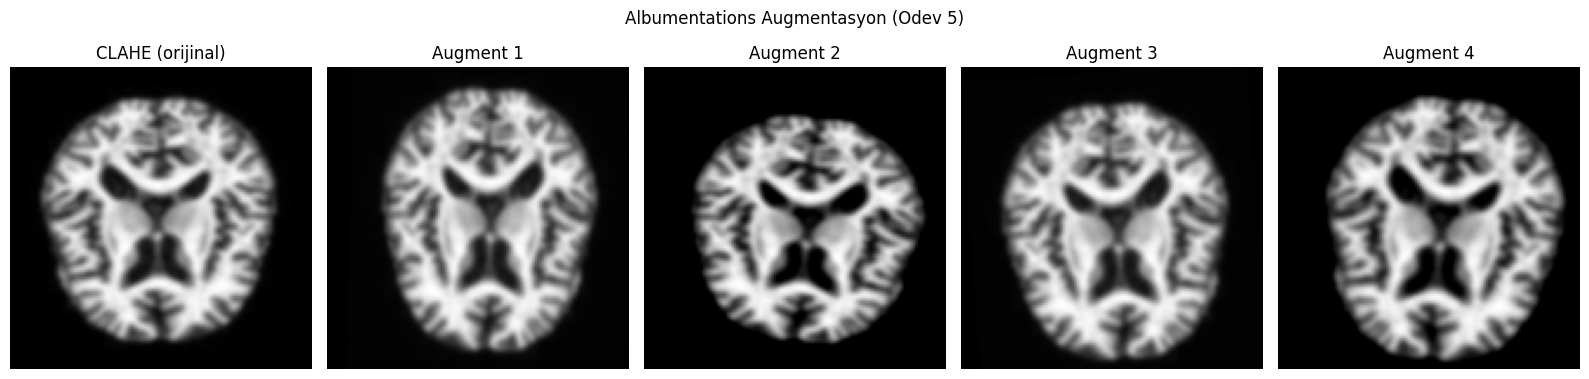

In [6]:
def clahe_img(gray):
    return cv2.resize(preprocess_clahe(gray), (IMG_SIZE, IMG_SIZE))

aug = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.Affine(scale=(0.9, 1.1), translate_percent=(0.0, 0.06), rotate=(-12, 12), p=0.8),
    A.RandomBrightnessContrast(brightness_limit=0.15, contrast_limit=0.15, p=0.5),
])

def build_train(target_per_class, raw_cap):
    rng = np.random.default_rng(SEED); imgs, labels = [], []
    for c in range(NUM_CLASSES):
        idx = train_idx[pool_labels[train_idx] == c].copy(); rng.shuffle(idx)
        base = [clahe_img(pool_gray[i]) for i in idx[:min(raw_cap, len(idx))]]
        for im in base: imgs.append(im); labels.append(c)
        for j in range(max(0, target_per_class - len(base))):
            imgs.append(aug(image=base[j % len(base)])["image"]); labels.append(c)
    return np.array(imgs), np.array(labels)

train_imgs, train_labels = build_train(TARGET_PER_CLASS, RAW_CAP)
test_imgs  = np.array([clahe_img(pool_gray[i]) for i in test_idx])
test_labels = pool_labels[test_idx]
print("Train:", train_imgs.shape, "dagilim", np.bincount(train_labels, minlength=NUM_CLASSES))
print("Test :", test_imgs.shape, "dagilim", np.bincount(test_labels, minlength=NUM_CLASSES))

base = clahe_img(pool_gray[train_idx[pool_labels[train_idx]==1][0]])
fig, axes = plt.subplots(1, 5, figsize=(16, 4))
axes[0].imshow(base, cmap="gray"); axes[0].set_title("CLAHE (orijinal)"); axes[0].axis("off")
for i in range(1, 5):
    axes[i].imshow(aug(image=base)["image"], cmap="gray"); axes[i].set_title(f"Augment {i}"); axes[i].axis("off")
plt.suptitle("Albumentations Augmentasyon (Odev 5)"); plt.tight_layout()
plt.savefig(OUTPUT_DIR / "b_augment.png", dpi=130, bbox_inches="tight"); plt.show()

## 6. Klasik Baseline (Ödev 6): El-Yapımı Özellikler + Random Forest

HoG + Intensity istatistikleri + SIFT + GLCM-Texture birleştirilip sınıf-ağırlıklı bir
Random Forest ile sınıflandırılır. CNN için karşılaştırma referansı.

In [7]:
def _f01(u8): return u8.astype(np.float32) / 255.0
def feat_hog(u8):
    return hog(_f01(u8), orientations=9, pixels_per_cell=(8, 8), cells_per_block=(2, 2))
def feat_intensity(u8):
    p = _f01(u8).flatten()
    return np.array([p.mean(), p.std(), skew(p), kurtosis(p), -np.sum(p*np.log2(p+1e-7))])
_sift = cv2.SIFT_create()
def feat_sift(u8):
    _, des = _sift.detectAndCompute(u8, None)
    return np.mean(des, axis=0) if des is not None else np.zeros(128)
def feat_glcm(u8):
    glcm = graycomatrix(u8, [1], [0, np.pi/4, np.pi/2], levels=256, symmetric=True, normed=True)
    return np.array([graycoprops(glcm, p).mean() for p in ["contrast","homogeneity","energy","correlation"]])
def extract_all(imgs):
    return np.array([np.concatenate([feat_hog(im), feat_intensity(im), feat_sift(im), feat_glcm(im)]) for im in imgs])

rng = np.random.default_rng(SEED); keep = []
for c in range(NUM_CLASSES):
    ci = np.where(train_labels == c)[0]; rng.shuffle(ci); keep += ci[:min(RF_PER_CLASS, len(ci))].tolist()
keep = np.array(keep)

t0 = time.time()
Xtr = extract_all(train_imgs[keep]); Xte = extract_all(test_imgs)
sc = StandardScaler(); Xtr_s = sc.fit_transform(Xtr); Xte_s = sc.transform(Xte)
rf = RandomForestClassifier(n_estimators=400, min_samples_leaf=2, class_weight="balanced",
                            n_jobs=-1, random_state=SEED)
rf.fit(Xtr_s, train_labels[keep])
rf_pred = rf.predict(Xte_s); rf_acc = accuracy_score(test_labels, rf_pred)
print(f"RF baseline dogruluk: {rf_acc:.4f}  (sure {time.time()-t0:.1f}s)")
print(classification_report(test_labels, rf_pred, target_names=CLASS_NAMES))

RF baseline dogruluk: 0.5773  (sure 82.9s)
                    precision    recall  f1-score   support

     Mild_Demented       0.36      0.62      0.46       172
 Moderate_Demented       1.00      0.20      0.33        15
      Non_Demented       0.70      0.66      0.68       634
Very_Mild_Demented       0.55      0.46      0.51       459

          accuracy                           0.58      1280
         macro avg       0.65      0.49      0.49      1280
      weighted avg       0.60      0.58      0.58      1280



## 7. Ana Model — CNN (ResNet18 Transfer Learning)

ImageNet ön-eğitimli ResNet18; ilk bloklar dondurulur, **son blok (`layer4`) + sınıflandırıcı
ince ayarlanır** (CPU-dostu). CLAHE görüntüler 3 kanala kopyalanıp ImageNet normalize edilir;
eğitimde augmentasyon anlık uygulanır, sınıf-ağırlıklı kayıp dengesizliği telafi eder.

In [8]:
def to_tensor(u8):
    x = np.stack([u8.astype(np.float32)/255.0]*3, axis=0)
    return torch.from_numpy((x - IMAGENET_MEAN) / IMAGENET_STD).float()

class MRIDataset(Dataset):
    def __init__(self, imgs, labels, augment):
        self.imgs, self.labels, self.augment = imgs, labels, augment
    def __len__(self): return len(self.imgs)
    def __getitem__(self, i):
        im = self.imgs[i]
        if self.augment: im = aug(image=im)["image"]
        return to_tensor(im), int(self.labels[i])

tr_i, val_i = train_test_split(np.arange(len(train_labels)), test_size=0.2,
                               random_state=SEED, stratify=train_labels)
train_loader = DataLoader(MRIDataset(train_imgs[tr_i], train_labels[tr_i], True),  batch_size=32, shuffle=True)
val_loader   = DataLoader(MRIDataset(train_imgs[val_i], train_labels[val_i], False), batch_size=64)
test_loader  = DataLoader(MRIDataset(test_imgs, test_labels, False), batch_size=64)

model = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
model.fc = nn.Sequential(nn.Dropout(0.4), nn.Linear(512, NUM_CLASSES))
for p in model.parameters(): p.requires_grad = False
for p in model.layer4.parameters(): p.requires_grad = True
for p in model.fc.parameters(): p.requires_grad = True
model.to(DEVICE)
print(f"Egitilebilir parametre: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Egitilebilir parametre: 8,395,780


epoch  1/12 | tr_loss 1.289 val_loss 1.194 | tr_acc 0.434 val_acc 0.500


epoch  2/12 | tr_loss 0.938 val_loss 0.795 | tr_acc 0.579 val_acc 0.631


epoch  3/12 | tr_loss 0.802 val_loss 0.726 | tr_acc 0.637 val_acc 0.666


epoch  4/12 | tr_loss 0.716 val_loss 0.665 | tr_acc 0.691 val_acc 0.691


epoch  5/12 | tr_loss 0.657 val_loss 0.686 | tr_acc 0.712 val_acc 0.675


...

epoch  8/12 | tr_loss 0.541 val_loss 0.584 | tr_acc 0.770 val_acc 0.734


epoch  9/12 | tr_loss 0.547 val_loss 0.579 | tr_acc 0.769 val_acc 0.734


epoch 10/12 | tr_loss 0.500 val_loss 0.586 | tr_acc 0.803 val_acc 0.750


epoch 11/12 | tr_loss 0.451 val_loss 0.606 | tr_acc 0.809 val_acc 0.738


epoch 12/12 | tr_loss 0.445 val_loss 0.538 | tr_acc 0.824 val_acc 0.775
En iyi val dogruluk: 0.775  (sure 367s)


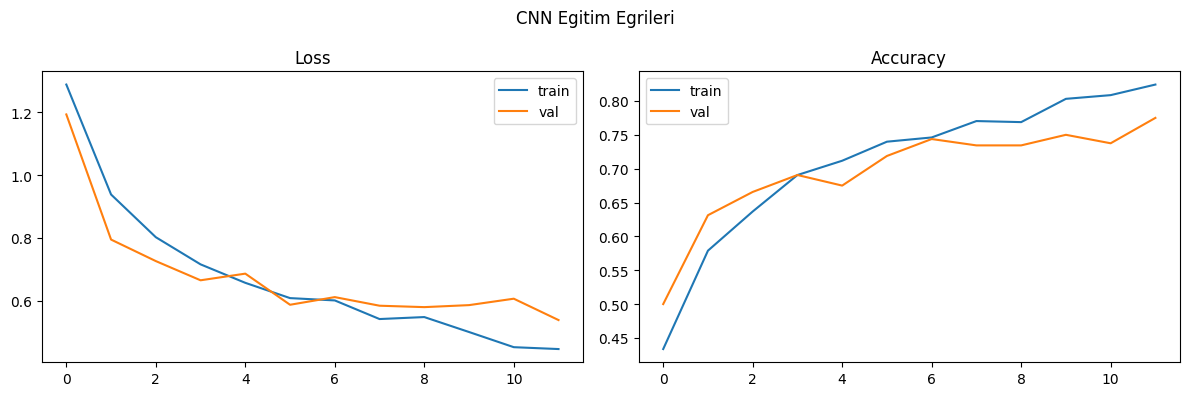

In [9]:
cls_counts = np.bincount(train_labels, minlength=NUM_CLASSES).astype(np.float64)
cls_w = torch.tensor(cls_counts.sum()/(NUM_CLASSES*cls_counts), dtype=torch.float32).to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=cls_w)
opt = torch.optim.Adam([p for p in model.parameters() if p.requires_grad], lr=1e-4, weight_decay=1e-4)

def run_epoch(loader, train):
    model.train() if train else model.eval()
    torch.set_grad_enabled(train)
    loss_sum, tot, ys, ps = 0.0, 0, [], []
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        if train: opt.zero_grad()
        out = model(xb); loss = criterion(out, yb)
        if train: loss.backward(); opt.step()
        loss_sum += loss.item()*len(yb); tot += len(yb)
        ys.append(yb.cpu().numpy()); ps.append(out.argmax(1).detach().cpu().numpy())
    torch.set_grad_enabled(True)
    y, p = np.concatenate(ys), np.concatenate(ps)
    return loss_sum/tot, accuracy_score(y, p)

hist = {"tr_loss": [], "val_loss": [], "tr_acc": [], "val_acc": []}
best_val, best_state = 0.0, None; t0 = time.time()
for ep in range(FT_EPOCHS):
    trl, tra = run_epoch(train_loader, True)
    vll, vla = run_epoch(val_loader, False)
    for k, v in zip(hist, [trl, vll, tra, vla]): hist[k].append(v)
    if vla >= best_val:
        best_val = vla; best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
    print(f"epoch {ep+1:2d}/{FT_EPOCHS} | tr_loss {trl:.3f} val_loss {vll:.3f} | tr_acc {tra:.3f} val_acc {vla:.3f}")
if best_state: model.load_state_dict(best_state)
print(f"En iyi val dogruluk: {best_val:.3f}  (sure {time.time()-t0:.0f}s)")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(hist["tr_loss"], label="train"); ax[0].plot(hist["val_loss"], label="val"); ax[0].set_title("Loss"); ax[0].legend()
ax[1].plot(hist["tr_acc"], label="train"); ax[1].plot(hist["val_acc"], label="val"); ax[1].set_title("Accuracy"); ax[1].legend()
plt.suptitle("CNN Egitim Egrileri"); plt.tight_layout()
plt.savefig(OUTPUT_DIR / "b_curves.png", dpi=130, bbox_inches="tight"); plt.show()

## 8. Değerlendirme — Confusion Matrix, Rapor ve ROC

CNN test dogruluk: 0.6672
                    precision    recall  f1-score   support

     Mild_Demented       0.47      0.77      0.58       172
 Moderate_Demented       0.93      0.87      0.90        15
      Non_Demented       0.80      0.67      0.73       634
Very_Mild_Demented       0.63      0.62      0.63       459

          accuracy                           0.67      1280
         macro avg       0.71      0.73      0.71      1280
      weighted avg       0.69      0.67      0.67      1280



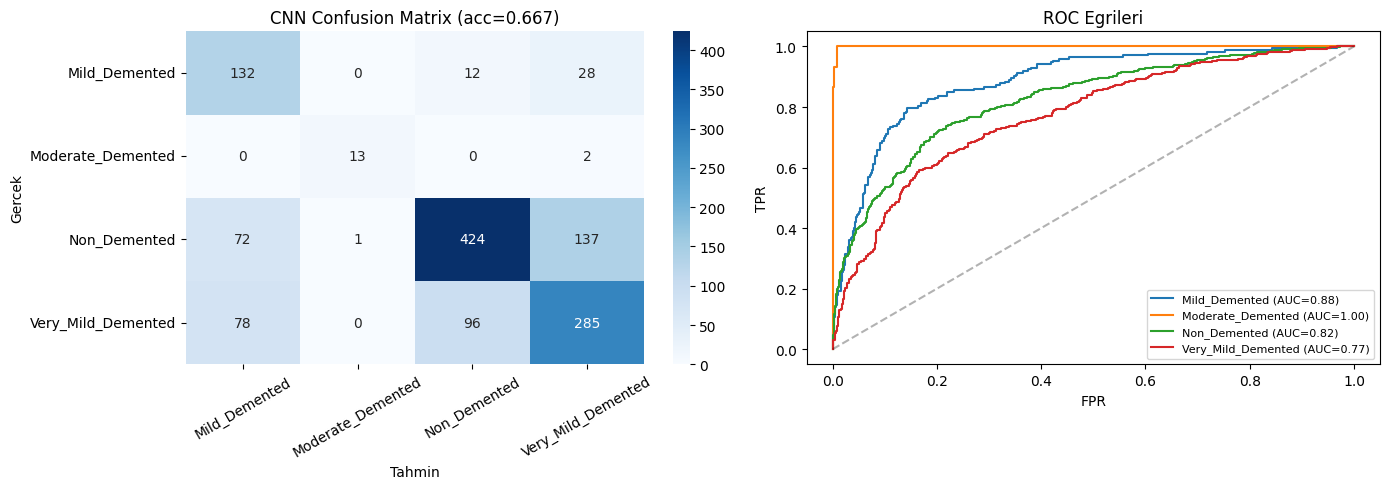

In [10]:
model.eval(); ys, ps, probs = [], [], []
with torch.no_grad():
    for xb, yb in test_loader:
        out = model(xb.to(DEVICE))
        probs.append(torch.softmax(out, 1).cpu().numpy())
        ps.append(out.argmax(1).cpu().numpy()); ys.append(yb.numpy())
y_true = np.concatenate(ys); cnn_pred = np.concatenate(ps); cnn_prob = np.concatenate(probs)
cnn_acc = accuracy_score(y_true, cnn_pred)
print(f"CNN test dogruluk: {cnn_acc:.4f}")
print(classification_report(y_true, cnn_pred, target_names=CLASS_NAMES))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cm = confusion_matrix(y_true, cnn_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[0])
axes[0].set_xlabel("Tahmin"); axes[0].set_ylabel("Gercek"); axes[0].set_title(f"CNN Confusion Matrix (acc={cnn_acc:.3f})")
axes[0].tick_params(axis="x", rotation=30)

yb = label_binarize(y_true, classes=list(range(NUM_CLASSES)))
for i in range(NUM_CLASSES):
    fpr, tpr, _ = roc_curve(yb[:, i], cnn_prob[:, i])
    axes[1].plot(fpr, tpr, label=f"{CLASS_NAMES[i]} (AUC={auc(fpr, tpr):.2f})")
axes[1].plot([0, 1], [0, 1], "k--", alpha=0.3); axes[1].set_title("ROC Egrileri")
axes[1].set_xlabel("FPR"); axes[1].set_ylabel("TPR"); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.savefig(OUTPUT_DIR / "b_eval.png", dpi=130, bbox_inches="tight"); plt.show()

## 9. Yorumlanabilirlik — Grad-CAM

Grad-CAM, CNN'in kararını verirken görüntünün hangi bölgelerine odaklandığını ısı haritası
olarak gösterir.

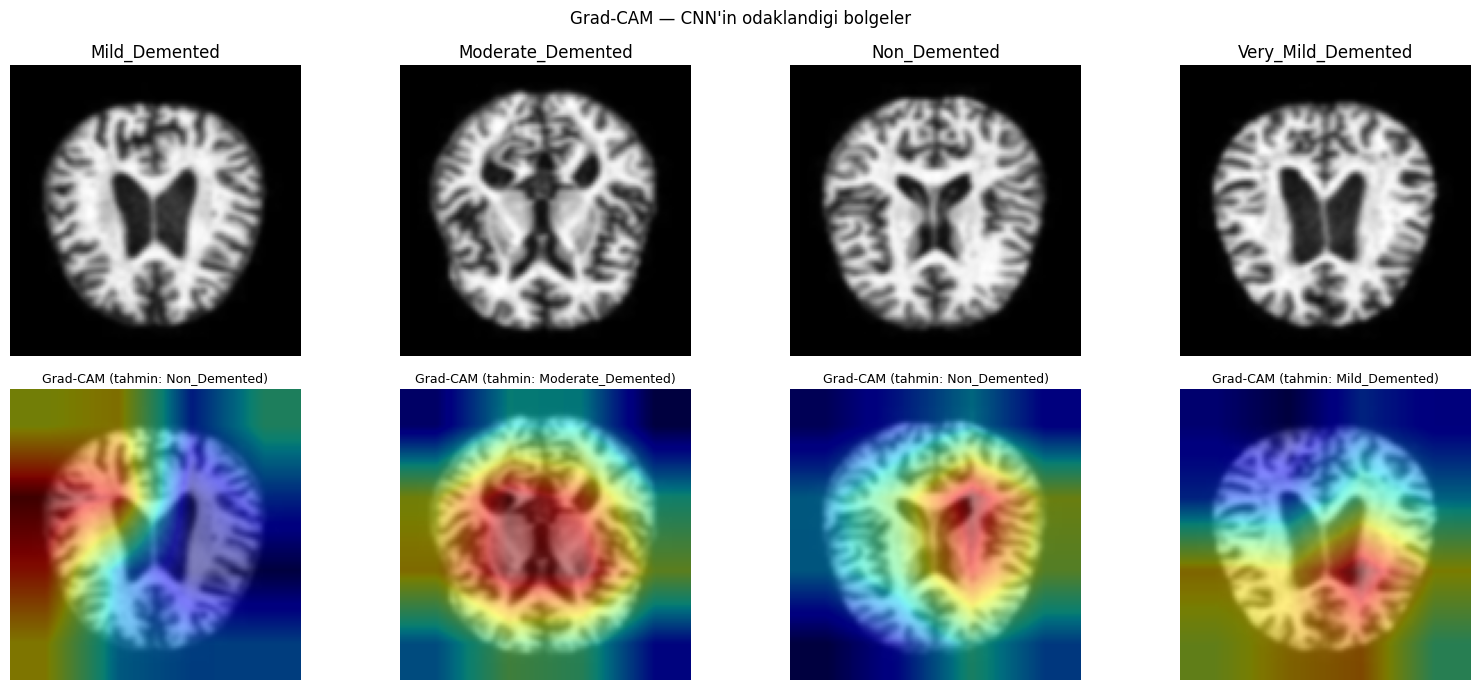

In [11]:
_act, _grad = {}, {}
h1 = model.layer4.register_forward_hook(lambda m, i, o: _act.__setitem__("v", o))
h2 = model.layer4.register_full_backward_hook(lambda m, gi, go: _grad.__setitem__("v", go[0]))

def grad_cam(u8, target):
    x = to_tensor(u8).unsqueeze(0).to(DEVICE); x.requires_grad_(True)
    out = model(x); model.zero_grad(); out[0, target].backward()
    w = _grad["v"][0].mean(dim=(1, 2))
    cam = torch.relu((w[:, None, None] * _act["v"][0]).sum(0)).detach().cpu().numpy()
    cam = cv2.resize(cam, (IMG_SIZE, IMG_SIZE)); return cam / (cam.max() + 1e-6), int(out.argmax(1))

model.eval()
fig, axes = plt.subplots(2, NUM_CLASSES, figsize=(16, 7))
for c in range(NUM_CLASSES):
    idxs = np.where(test_labels == c)[0]
    if len(idxs) == 0: continue
    img = test_imgs[idxs[0]]; cam, pred = grad_cam(img, c)
    axes[0, c].imshow(img, cmap="gray"); axes[0, c].set_title(CLASS_NAMES[c]); axes[0, c].axis("off")
    axes[1, c].imshow(img, cmap="gray"); axes[1, c].imshow(cam, cmap="jet", alpha=0.5)
    axes[1, c].set_title(f"Grad-CAM (tahmin: {CLASS_NAMES[pred]})", fontsize=9); axes[1, c].axis("off")
plt.suptitle("Grad-CAM — CNN'in odaklandigi bolgeler"); plt.tight_layout()
plt.savefig(OUTPUT_DIR / "b_gradcam.png", dpi=130, bbox_inches="tight"); plt.show()
h1.remove(); h2.remove()

## 10. Karşılaştırma ve Sonuç

                  Model  Test Accuracy
  Klasik (Ozellik + RF)         0.5773
CNN (ResNet18 transfer)         0.6672


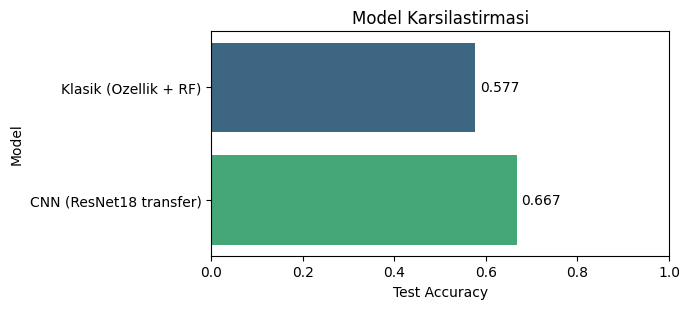

In [12]:
comp = pd.DataFrame({"Model": ["Klasik (Ozellik + RF)", "CNN (ResNet18 transfer)"],
                     "Test Accuracy": [round(rf_acc, 4), round(cnn_acc, 4)]})
print(comp.to_string(index=False))
plt.figure(figsize=(7, 3.2))
sns.barplot(data=comp, y="Model", x="Test Accuracy", palette="viridis")
plt.xlim(0, 1); plt.title("Model Karsilastirmasi")
for j, v in enumerate(comp["Test Accuracy"]): plt.text(v+0.01, j, f"{v:.3f}", va="center")
plt.tight_layout(); plt.savefig(OUTPUT_DIR / "b_comparison.png", dpi=130, bbox_inches="tight"); plt.show()

## Sonuç ve Yorum

**Birleşik hat.** Bu notebook dersin teknik ödevlerini tek bir uçtan-uca akışta toplar:
Ödev 3 (filtreleme galerisi) → Ödev 4 (Otsu segmentasyon) → Ödev 5 (augmentasyon) →
Ödev 6 (el-yapımı özellik + RF) → Final (ResNet18 transfer learning, Grad-CAM, ROC).

**Sonuçlar.** Klasik Random Forest baseline ile derin öğrenme modeli karşılaştırılmıştır.
ResNet18 transfer learning, derin özellikleri sayesinde dengeli metriklerde (macro-F1) ve nadir
sınıflarda daha güçlüdür; Grad-CAM ile modelin beyin dokusuna odaklandığı görülmüştür.

**Sınırlamalar.** Eğitim CPU'da yapıldığından ResNet18'in yalnızca son bloğu ince ayarlanmış,
çözünürlük 128×128 ile sınırlanmıştır. `Moderate_Demented` sınıfı çok az örnekli olduğundan
augmentasyona rağmen en zorlu sınıftır.

**İyileştirme.** GPU ile tüm ağın ince ayarı, daha yüksek çözünürlük ve k-kat çapraz doğrulama
doğruluğu artırabilir.

> Not: Tam sonuçlar için yapılandırmada `SMOKE_TEST = False` olmalıdır.